# KarirNex Data Analyst Task Day 3

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from google.colab import files
uploaded = files.upload()

Saving furniture_10k_FINAL.xlsx to furniture_10k_FINAL (3).xlsx


In [31]:
excel = pd.ExcelFile("furniture_10k_FINAL.xlsx")

print(excel.sheet_names)

['Sheet1']


In [32]:
df = pd.read_excel("furniture_10k_FINAL.xlsx", sheet_name="Sheet1")

In [33]:
df.head()

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address
0,2025-07-31,ORD00001,Customer_332,Kitchen Set,Dapur,9500000,1,0.0,9500000,60000,9560000,cancelled,"Kelurahan 120, Jakarta Pusat"
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0.0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat"
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0.0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat"
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0.0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor"
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang"


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sales_date        10000 non-null  object 
 1   order_id          10000 non-null  object 
 2   customer_name     10000 non-null  object 
 3   product_name      10000 non-null  object 
 4   category          10000 non-null  object 
 5   price             10000 non-null  int64  
 6   quantity          10000 non-null  int64  
 7   discount          10000 non-null  float64
 8   total             10000 non-null  int64  
 9   shipping_fee      10000 non-null  int64  
 10  total_sales       10000 non-null  int64  
 11  status            10000 non-null  object 
 12  shipping_address  10000 non-null  object 
dtypes: float64(1), int64(5), object(7)
memory usage: 1015.8+ KB


# Challenge 1 - Data Cleansing

In [35]:
df.head()

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address
0,2025-07-31,ORD00001,Customer_332,Kitchen Set,Dapur,9500000,1,0.0,9500000,60000,9560000,cancelled,"Kelurahan 120, Jakarta Pusat"
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0.0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat"
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0.0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat"
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0.0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor"
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang"


In [36]:
# 1. Membaca dataset dari file Excel
df = pd.read_excel("furniture_10k_FINAL.xlsx", sheet_name="Sheet1")

# Menampilkan 5 baris pertama dataset
df.head()

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address
0,2025-07-31,ORD00001,Customer_332,Kitchen Set,Dapur,9500000,1,0.0,9500000,60000,9560000,cancelled,"Kelurahan 120, Jakarta Pusat"
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0.0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat"
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0.0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat"
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0.0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor"
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang"


In [37]:
# 2. # Mengecek dan menghapus data duplikat
duplicate = df.duplicated().sum()
print("Jumlah data duplikat:", duplicate)

df = df.drop_duplicates()

print("Jumlah data setelah menghapus duplikat:", len(df))

Jumlah data duplikat: 0
Jumlah data setelah menghapus duplikat: 10000


In [38]:
# 3. Mengecek jumlah missing values pada setiap kolom
print(df.isnull().sum())

df["shipping_address"] = df["shipping_address"].fillna("Unknown")

sales_date          0
order_id            0
customer_name       0
product_name        0
category            0
price               0
quantity            0
discount            0
total               0
shipping_fee        0
total_sales         0
status              0
shipping_address    0
dtype: int64


In [39]:
# 4. Mengubah tipe data sales_date menjadi datetime
df["sales_date"] = pd.to_datetime(df["sales_date"])

# Menampilkan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_date        10000 non-null  datetime64[ns]
 1   order_id          10000 non-null  object        
 2   customer_name     10000 non-null  object        
 3   product_name      10000 non-null  object        
 4   category          10000 non-null  object        
 5   price             10000 non-null  int64         
 6   quantity          10000 non-null  int64         
 7   discount          10000 non-null  float64       
 8   total             10000 non-null  int64         
 9   shipping_fee      10000 non-null  int64         
 10  total_sales       10000 non-null  int64         
 11  status            10000 non-null  object        
 12  shipping_address  10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(6)
memory usage: 1015.8+ K

#Challenge 2 - Data Aggregation & Plotting

In [40]:
# 1. Ekstraksi Kota
df["city"] = df["shipping_address"].str.split(",").str[-1].str.strip()

# Menampilkan hasil ekstraksi
df[["shipping_address", "city"]].head()

,shipping_address,city
0,"Kelurahan 120, Jakarta Pusat",Jakarta Pusat
1,"Kelurahan 9, Jakarta Pusat",Jakarta Pusat
2,"Kelurahan 108, Jakarta Pusat",Jakarta Pusat
3,"Kelurahan 36, Bogor",Bogor
4,"Kelurahan 73, Tangerang",Tangerang


In [41]:
# 2. Filter transaksi dengan status completed
completed = df[df["status"] == "completed"]

# Menampilkan jumlah transaksi completed
print("Jumlah transaksi completed:", len(completed))

completed.head()

Jumlah transaksi completed: 8972


,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address,city
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0.0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat",Jakarta Pusat
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0.0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat",Jakarta Pusat
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0.0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor",Bogor
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang",Tangerang
5,2025-01-11,ORD00006,Customer_793,Lemari Dapur,Dapur,1850000,1,0.0,1850000,60000,1910000,completed,"Kelurahan 176, Tangerang",Tangerang


In [42]:
# 3.  Groupby Kota
# Menghitung total penjualan berdasarkan kota
city_sales = (
    completed
    .groupby("city")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

city_sales

,total_sales
city,
Jakarta Utara,5068862000
Jakarta Barat,5021356500
Jakarta Pusat,4996988000
Depok,4854175000
Bogor,4811721500
Jakarta Selatan,4764095500
Jakarta Timur,4666865000
Tangerang Selatan,4544961500
Tangerang,4415711500


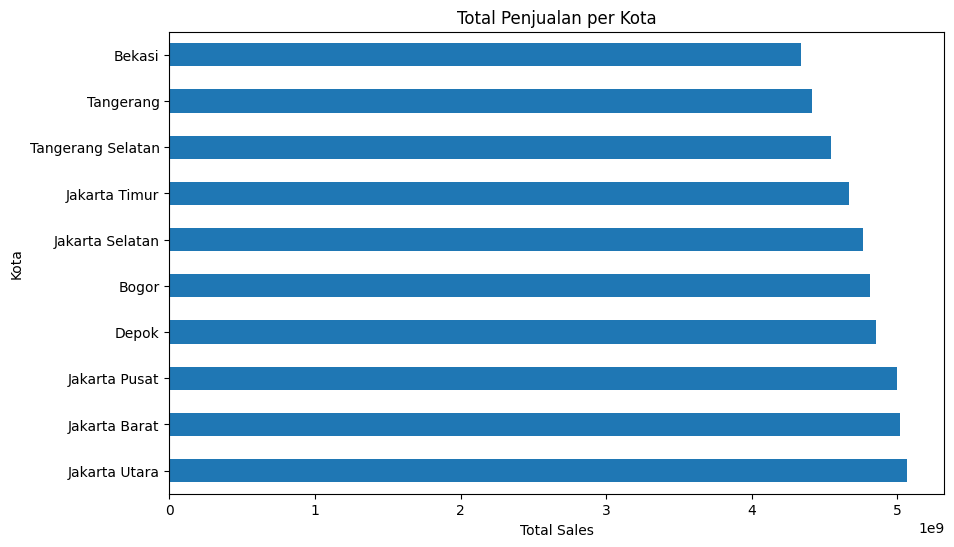

In [43]:
# 4. bar chart
plt.figure(figsize=(10,6))

city_sales.plot(kind="barh")

plt.title("Total Penjualan per Kota")
plt.xlabel("Total Sales")
plt.ylabel("Kota")

plt.show()

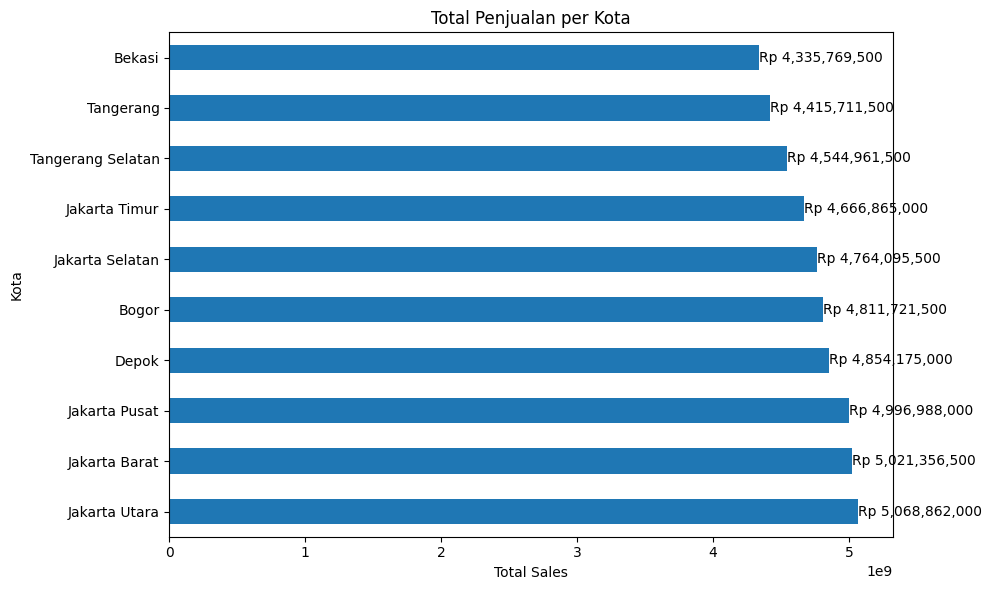

In [44]:
# Membuat horizontal bar chart dengan label nilai rupiah
fig, ax = plt.subplots(figsize=(10,6))

city_sales.plot(kind="barh", ax=ax)

for i, value in enumerate(city_sales):
    ax.text(value, i, f"Rp {value:,.0f}", va="center")

plt.title("Total Penjualan per Kota")
plt.xlabel("Total Sales")
plt.ylabel("Kota")

plt.tight_layout()
plt.show()

# Challenge 3 - Dashboard & Business Insight

In [45]:
# 1. Filter pesanan promosi
promo = df[(df["status"] == "completed") & (df["discount"] > 0)]

# Menampilkan jumlah data dan 5 baris pertama
print("Jumlah transaksi promosi:", len(promo))
promo.head()

Jumlah transaksi promosi: 293


,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address,city
9,2025-04-04,ORD00010,Customer_478,Lemari TV,Ruang Tamu,2300000,1,0.1,2070000,50000,2120000,completed,"Kelurahan 94, Depok",Depok
27,2025-12-12,ORD00028,Customer_2282,Rak Sepatu,Penyimpanan,650000,2,0.1,1170000,60000,1230000,completed,"Kelurahan 44, Jakarta Selatan",Jakarta Selatan
35,2025-01-01,ORD00036,Customer_1985,Lemari Baju,Kamar Tidur,3500000,2,0.1,6300000,60000,6360000,completed,"Kelurahan 90, Tangerang Selatan",Tangerang Selatan
42,2025-10-10,ORD00043,Customer_59,Lemari Sliding,Kamar Tidur,4750000,3,0.1,12825000,60000,12885000,completed,"Kelurahan 9, Jakarta Pusat",Jakarta Pusat
44,2025-10-10,ORD00045,Customer_3025,Lemari Laci,Kamar Tidur,1950000,3,0.1,5265000,60000,5325000,completed,"Kelurahan 102, Jakarta Selatan",Jakarta Selatan


In [46]:
# 2. Agregasi produk
# Menghitung total omzet, rata-rata diskon, dan rata-rata quantity per produk
product_summary = (
    promo
    .groupby("product_name")
    .agg(
        total_omset=("total_sales", "sum"),
        rata_diskon=("discount", "mean"),
        rata_quantity=("quantity", "mean")
    )
    .sort_values(by="total_omset", ascending=False)
)

# Menampilkan 10 produk dengan omzet terbesar
product_summary.head(10)

,total_omset,rata_diskon,rata_quantity
product_name,,,
Kitchen Set,214530000,0.1,1.785714
Kasur,139400000,0.1,2.000000
Lemari Baju,114480000,0.1,1.894737
Lemari Sliding,107435000,0.1,2.500000
Bufet,106270000,0.1,2.117647
Sofa,101870000,0.1,2.272727
Lemari TV,79670000,0.1,2.111111
Lemari Dapur,67880000,0.1,1.739130
Lemari Sudut,62615000,0.1,1.923077


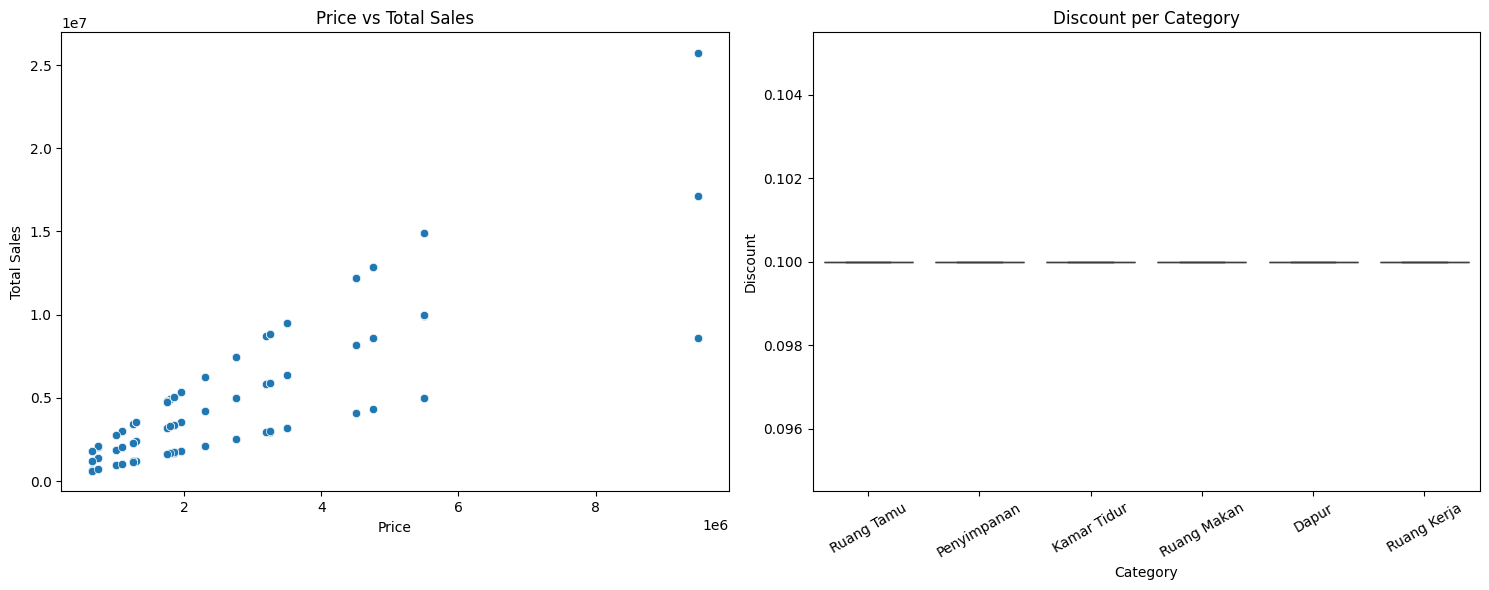

In [47]:
# 3. Desain Dashboard Subplots
# Membuat dashboard sederhana (2 subplot dalam 1 figure)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Scatter Plot: Price vs Total Sales
sns.scatterplot(
    data=promo,
    x="price",
    y="total_sales",
    ax=ax[0]
)

ax[0].set_title("Price vs Total Sales")
ax[0].set_xlabel("Price")
ax[0].set_ylabel("Total Sales")

# Boxplot: Discount per Category
sns.boxplot(
    data=promo,
    x="category",
    y="discount",
    ax=ax[1]
)

ax[1].set_title("Discount per Category")
ax[1].set_xlabel("Category")
ax[1].set_ylabel("Discount")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Business Insight

### 1. Fokuskan promosi pada produk dengan nilai penjualan tinggi
Scatter plot menunjukkan adanya kecenderungan hubungan positif antara harga produk dan total penjualan. Produk dengan harga lebih tinggi mampu menghasilkan total penjualan yang lebih besar sehingga dapat menjadi fokus utama dalam program promosi untuk meningkatkan omzet.

### 2. Terapkan strategi diskon yang lebih bervariasi
Visualisasi menunjukkan bahwa seluruh kategori menggunakan tingkat diskon yang sama, yaitu sekitar 10%. Tim marketing dapat mempertimbangkan variasi diskon pada setiap kategori agar strategi promosi lebih efektif dan sesuai dengan karakteristik masing-masing kategori produk.

### 3. Optimalkan strategi harga berdasarkan pola penjualan
Hubungan positif antara harga dan total penjualan menunjukkan bahwa tidak semua produk memerlukan diskon besar untuk tetap menghasilkan penjualan yang tinggi. Oleh karena itu, produk dengan penjualan yang sudah baik dapat mempertahankan diskon yang lebih kecil, sedangkan produk dengan penjualan yang lebih rendah dapat didukung melalui program promosi atau bundling untuk meningkatkan daya tarik pelanggan.
